In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np
from itertools import product
from sklearn.linear_model import Lasso
from tqdm import tqdm
from xgboost import XGBRegressor
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import ParameterGrid
import xgboost as xgb
from joblib import Parallel, delayed
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

## 1. Merging Stock Data with Text Features

---

#### Data Sources

- `final_stock_data_with_signal.csv`: structured stock-level features  
- `finbert_weighted_pca.csv`: PCA-reduced FinBERT embeddings with sentiment weighting  

---

#### Preprocessing

- Convert date columns to `datetime` format  
- Rename `Date` to `date`, `Stock_symbol` to `ticker` for consistency  

---

#### Merge Procedure

- Use `left join` on `date` and `ticker`   

---

#### Missing Values

- Fill missing values with `0`  

---

#### Output

- Save merged dataset to `merged_stock_with_text_features.csv`  

In [2]:
df_stock = pd.read_csv("final_stock_data_with_signal.csv")
df_text = pd.read_csv("finbert_weighted_pca.csv")

# 1. Convert date columns to datetime format
df_stock['date'] = pd.to_datetime(df_stock['date'])
df_text['Date'] = pd.to_datetime(df_text['Date'])

# 2. Rename columns to unify merge keys
df_text = df_text.rename(columns={
    'Date': 'date',
    'Stock_symbol': 'ticker'
})

# 3. Merge the two DataFrames using a left join (stock data as the base)
df = pd.merge(df_stock, df_text, on=['date', 'ticker'], how='left')

In [3]:
# Display number of missing (NaN) values in each column
print(df.isna().sum())

# Replace all NaN values with 0 in merged_df
df = df.fillna(0)

# Save the merged DataFrame to a CSV file
df.to_csv("merged_stock_with_text_features.csv", index=False)

date                                    0
ticker                                  0
PX_HIGH                                 0
PX_LOW                                  0
PX_OPEN                                 0
PX_LAST                                 0
PX_VOLUME                               0
PE_RATIO                                0
PX_TO_BOOK_RATIO                        0
PX_TO_SALES_RATIO                       0
DAY_TO_DAY_TOT_RETURN_GROSS_DVDS        0
CUR_MKT_CAP                             0
IVOL_DELTA                              0
IVOL_IMPLIED_FORWARD                    0
fwd_return_1d                           0
fwd_return_5d                           0
fwd_return_20d                          0
fwd_return_40d                          0
daily_rf_return                         0
vrp_std_250                             0
PE_RATIO_signal_60                      0
PX_TO_BOOK_RATIO_signal_60              0
PX_TO_SALES_RATIO_signal_60             0
PX_LAST_EWMA_signal_span60        

In [4]:
def create_expanding_cv_splits(df, test_years, train_years=5, min_cv_folds=5):
    """
    Generate roll-forward expanding cross-validation splits:
    - Train period expands
    - Fixed 6-month validation window
    - One test year per split

    Returns:
        splits: list of dicts
    """
    splits = []

    for test_year in test_years:
        test_start = pd.Timestamp(f"{test_year}-01-01")
        test_end = pd.Timestamp(f"{test_year}-12-31")
        train_start = test_start - pd.DateOffset(years=train_years)
        train_end = test_start - pd.Timedelta(days=1)

        # Get sorted unique dates in training range
        train_dates = df[(df['date'] >= train_start) & (df['date'] <= train_end)]['date'].drop_duplicates().sort_values().reset_index(drop=True)
        if len(train_dates) == 0:
            continue

        # First validation starts at train_start + 2.5y
        val_start = train_start + pd.DateOffset(years=2, months=6)
        val_folds = []

        while True:
            val_end = (val_start + pd.DateOffset(months=6)) - pd.DateOffset(months=1)
            val_end = pd.Timestamp(val_end.year, val_end.month, 1) + pd.offsets.MonthEnd(0)

            if val_end > train_end:
                break

            train_fold_end = val_start - pd.Timedelta(days=1)

            val_folds.append({
                'train_start': train_start,
                'train_end': train_fold_end,
                'val_start': val_start,
                'val_end': val_end
            })

            # Slide validation window forward by 6 months
            val_start += pd.DateOffset(months=6)

        if len(val_folds) < min_cv_folds:
            continue

        splits.append({
            'test_year': test_year,
            'train_period': (train_start, train_end),
            'test_period': (test_start, test_end),
            'cv_folds': val_folds
        })

    return splits

df['date'] = pd.to_datetime(df['date'])
splits = create_expanding_cv_splits(df, test_years=[2017, 2018, 2019, 2020])

# Print split structure
for s in splits:
    print(f"\nTest Year: {s['test_year']}")
    print(f"  Train : {s['train_period'][0].date()} ~ {s['train_period'][1].date()}")
    print(f"  Test  : {s['test_period'][0].date()} ~ {s['test_period'][1].date()}")
    for i, fold in enumerate(s['cv_folds'], 1):
        print(f"    CV Fold {i}:")
        print(f"      Train : {fold['train_start'].date()} ~ {fold['train_end'].date()}")
        print(f"      Val   : {fold['val_start'].date()} ~ {fold['val_end'].date()}")


Test Year: 2017
  Train : 2012-01-01 ~ 2016-12-31
  Test  : 2017-01-01 ~ 2017-12-31
    CV Fold 1:
      Train : 2012-01-01 ~ 2014-06-30
      Val   : 2014-07-01 ~ 2014-12-31
    CV Fold 2:
      Train : 2012-01-01 ~ 2014-12-31
      Val   : 2015-01-01 ~ 2015-06-30
    CV Fold 3:
      Train : 2012-01-01 ~ 2015-06-30
      Val   : 2015-07-01 ~ 2015-12-31
    CV Fold 4:
      Train : 2012-01-01 ~ 2015-12-31
      Val   : 2016-01-01 ~ 2016-06-30
    CV Fold 5:
      Train : 2012-01-01 ~ 2016-06-30
      Val   : 2016-07-01 ~ 2016-12-31

Test Year: 2018
  Train : 2013-01-01 ~ 2017-12-31
  Test  : 2018-01-01 ~ 2018-12-31
    CV Fold 1:
      Train : 2013-01-01 ~ 2015-06-30
      Val   : 2015-07-01 ~ 2015-12-31
    CV Fold 2:
      Train : 2013-01-01 ~ 2015-12-31
      Val   : 2016-01-01 ~ 2016-06-30
    CV Fold 3:
      Train : 2013-01-01 ~ 2016-06-30
      Val   : 2016-07-01 ~ 2016-12-31
    CV Fold 4:
      Train : 2013-01-01 ~ 2016-12-31
      Val   : 2017-01-01 ~ 2017-06-30
    CV Fold

## 2. Feature Classification and Remove

---

### Step 1: Identify Non-Feature Columns

Mark columns that should not be used as inputs for the model. These include:

- Date columns  
- Ticker or stock IDs  
- Forward return columns  
- Risk-free rate columns

---

### Step 2: Select Features

From the full dataset, keep only the columns not listed above. These will be the candidate input features for the model.

---

### Step 3: Split Features by Type

Split the features into two groups:

- **Categorical features**: columns with 10 or fewer unique values  
- **Continuous features**: columns with more than 10 unique values  

---

### Step 4: Remove Duplicate Inputs

Drop raw input columns that were already used to build signal features. This avoids repeating the same information.

- Price levels  
- Valuation ratios  
- Market cap  
- Implied volatility  

In [5]:
# Exclude non-feature columns
exclude_cols = ['date', 'ticker', 'fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d', 'daily_rf_return']
feature_cols = [col for col in df.columns if col not in exclude_cols]

# Classify features
categorical_threshold = 10  
categorical_features = []
continuous_features = []

for col in feature_cols:
    try:
        if df[col].nunique() <= categorical_threshold:
            categorical_features.append(col)
        else:
            continuous_features.append(col)
    except:
        continue

In [6]:
print("Categorical features:")
print(categorical_features)

print("\nContinuous features:")
print(continuous_features)

Categorical features:
['classic_breakout_60_20']

Continuous features:
['PX_HIGH', 'PX_LOW', 'PX_OPEN', 'PX_LAST', 'PX_VOLUME', 'PE_RATIO', 'PX_TO_BOOK_RATIO', 'PX_TO_SALES_RATIO', 'DAY_TO_DAY_TOT_RETURN_GROSS_DVDS', 'CUR_MKT_CAP', 'IVOL_DELTA', 'IVOL_IMPLIED_FORWARD', 'vrp_std_250', 'PE_RATIO_signal_60', 'PX_TO_BOOK_RATIO_signal_60', 'PX_TO_SALES_RATIO_signal_60', 'PX_LAST_EWMA_signal_span60', 'crossover_signal', 'cont_breakout_mu60_lam5_d0.9', 'RSI_signal_60', 'momentum_60d', 'momentum_20d', 'momentum_200d', 'momentum_220d', 'momentum_80d', 'macd_signal_15_60', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10']


In [7]:
# List of raw input columns to remove (already used to create signals)
raw_cols_to_drop = [
    'PX_HIGH', 'PX_LOW', 'PX_OPEN', 'PX_LAST', 'PX_VOLUME',
    'PE_RATIO', 'PX_TO_BOOK_RATIO', 'PX_TO_SALES_RATIO',
    'DAY_TO_DAY_TOT_RETURN_GROSS_DVDS', 'CUR_MKT_CAP',
    'IVOL_DELTA', 'IVOL_IMPLIED_FORWARD'
]

# Drop these columns only if they exist in the dataframe
df = df.drop(columns=[col for col in raw_cols_to_drop if col in df.columns])

# print remaining column names for inspection
print(df.columns.tolist())

['date', 'ticker', 'fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d', 'daily_rf_return', 'vrp_std_250', 'PE_RATIO_signal_60', 'PX_TO_BOOK_RATIO_signal_60', 'PX_TO_SALES_RATIO_signal_60', 'PX_LAST_EWMA_signal_span60', 'crossover_signal', 'classic_breakout_60_20', 'cont_breakout_mu60_lam5_d0.9', 'RSI_signal_60', 'momentum_60d', 'momentum_20d', 'momentum_200d', 'momentum_220d', 'momentum_80d', 'macd_signal_15_60', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10']


## 3. Main Model selection and Evaluation Metrics

---

#### Models Used

Two regression models are applied to predict forward returns:

- **LASSO (Least Absolute Shrinkage and Selection Operator)**:  
  A linear model with L1 regularization, used for feature selection.

- **XGBoost (Extreme Gradient Boosting)**:  
  A tree-based ensemble model that captures nonlinear interactions and is optimized for predictive performance.

---

#### Evaluation Metrics

Each model is evaluated using two key metrics:

- **MSE (Mean Squared Error)**:  
  Measures the average squared difference between predicted and actual returns. Lower values indicate better fit.

- **IC (Information Coefficient)**:  
  Spearman rank correlation between predictions and actual values. Reflects the model's ability to rank stocks correctly. Higher values indicate stronger predictive ordering.

---

#### Rolling Model Framework

A rolling expanding-window approach is used for model training and evaluation:

- For each **test year**, the preceding **five years** of data are used for training  
- A series of **six-month validation folds** are created within the training period for hyperparameter tuning  
- The best model is selected based on validation performance, then retrained on the full training set  
- Final evaluation is performed on the test year

---

In [8]:
'''

# Step 1: Date Parsing
df['date'] = pd.to_datetime(df['date'])

# Step 2: Feature Setup
forward_targets = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'fwd_return_40d']
exclude_cols = ['date', 'ticker', 'daily_rf_return'] + forward_targets
feature_cols = [c for c in df.columns if c not in exclude_cols]

# Step 3: Param Grid Search
def param_grid_dicts(grid):
    keys = list(grid.keys())
    for values in product(*[grid[k] for k in keys]):
        yield dict(zip(keys, values))

# Step 4: Evaluate on Folds
def evaluate_on_folds(df, folds, features, target, model_name, params):
    mse_list, ic_list = [], []

    for fold in folds:
        train_mask = (df['date'] >= fold['train_start']) & (df['date'] <= fold['train_end'])
        val_mask = (df['date'] >= fold['val_start']) & (df['date'] <= fold['val_end'])

        X_train = df.loc[train_mask, features].fillna(0.0).values
        y_train = df.loc[train_mask, target].values
        X_val = df.loc[val_mask, features].fillna(0.0).values
        y_val = df.loc[val_mask, target].values

        if model_name == 'lasso':
            model = Lasso(**params, random_state=42, max_iter=10000)
        elif model_name == 'xgb':
            model = XGBRegressor(**params, random_state=42)
        else:
            raise ValueError("Unknown model_name.")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse_list.append(mean_squared_error(y_val, y_pred))
        ic_list.append(spearmanr(y_val, y_pred).correlation)

    return float(np.mean(mse_list)), float(np.mean(ic_list))

# Step 5: Expanding CV Splits
def create_expanding_cv_splits(df, test_years, train_years=5, min_cv_folds=5):
    splits = []
    for test_year in test_years:
        test_start = pd.Timestamp(f"{test_year}-01-01")
        test_end = pd.Timestamp(f"{test_year}-12-31")
        train_start = test_start - pd.DateOffset(years=train_years)
        train_end = test_start - pd.Timedelta(days=1)

        val_start = train_start + pd.DateOffset(years=2, months=6)
        val_folds = []

        while True:
            val_end = (val_start + pd.DateOffset(months=6)) - pd.DateOffset(months=1)
            val_end = pd.Timestamp(val_end.year, val_end.month, 1) + pd.offsets.MonthEnd(0)
            if val_end > train_end:
                break
            train_fold_end = val_start - pd.Timedelta(days=1)
            val_folds.append({
                'train_start': train_start, 'train_end': train_fold_end,
                'val_start': val_start, 'val_end': val_end
            })
            val_start += pd.DateOffset(months=6)

        if len(val_folds) >= min_cv_folds:
            splits.append({
                'test_year': test_year,
                'train_period': (train_start, train_end),
                'test_period': (test_start, test_end),
                'cv_folds': val_folds
            })
    return splits

# Step 6: Rolling Training
def run_roll_training(df, test_years):
    results = []

    lasso_grid = {'alpha': np.logspace(-8, -3, 10)}
    xgb_grid = {
        'n_estimators': [200,500],
        'max_depth': [5, 10],
        'learning_rate': [0.05, 0.1],
        'subsample': [0.8],
        'colsample_bytree': [0.8],
        'tree_method': ['hist'],
        'n_jobs': [-1]
    }

    splits = create_expanding_cv_splits(df, test_years=test_years)

    for split in tqdm(splits, desc="Rolling Test Years"):
        test_year = split['test_year']
        train_start, train_end = split['train_period']
        test_start, test_end = split['test_period']
        folds = split['cv_folds']

        full_train_df = df[(df['date'] >= train_start) & (df['date'] <= train_end)]
        test_df = df[(df['date'] >= test_start) & (df['date'] <= test_end)]

        for target in tqdm(forward_targets, desc=f"[{test_year}] Target", leave=False):
            # LASSO
            best_mse, best_ic, best_params = np.inf, -np.inf, None
            for p in tqdm(list(param_grid_dicts(lasso_grid)), desc="LASSO Grid", leave=False):
                cv_mse, cv_ic = evaluate_on_folds(df, folds, feature_cols, target, 'lasso', p)
                if (cv_mse < best_mse) or (np.isclose(cv_mse, best_mse) and cv_ic > best_ic):
                    best_mse, best_ic, best_params = cv_mse, cv_ic, p.copy()

            lasso_model = Lasso(**best_params, random_state=42, max_iter=10000)
            lasso_model.fit(full_train_df[feature_cols].fillna(0.0), full_train_df[target])
            y_pred = lasso_model.predict(test_df[feature_cols].fillna(0.0))

            results.append({
                'test_year': test_year,
                'target': target,
                'model': 'LASSO',
                'cv_mse': best_mse,
                'cv_ic': best_ic,
                'test_mse': mean_squared_error(test_df[target], y_pred),
                'test_ic': spearmanr(test_df[target], y_pred).correlation,
                'best_params': best_params
            })

            # XGBoost
            best_mse, best_ic, best_params = np.inf, -np.inf, None
            for p in tqdm(list(param_grid_dicts(xgb_grid)), desc="XGB Grid", leave=False):
                cv_mse, cv_ic = evaluate_on_folds(df, folds, feature_cols, target, 'xgb', p)
                if (cv_mse < best_mse) or (np.isclose(cv_mse, best_mse) and cv_ic > best_ic):
                    best_mse, best_ic, best_params = cv_mse, cv_ic, p.copy()

            xgb_model = XGBRegressor(**best_params, random_state=42)
            xgb_model.fit(full_train_df[feature_cols].fillna(0.0), full_train_df[target])
            y_pred = xgb_model.predict(test_df[feature_cols].fillna(0.0))

            results.append({
                'test_year': test_year,
                'target': target,
                'model': 'XGBoost',
                'cv_mse': best_mse,
                'cv_ic': best_ic,
                'test_mse': mean_squared_error(test_df[target], y_pred),
                'test_ic': spearmanr(test_df[target], y_pred).correlation,
                'best_params': best_params
            })

    return pd.DataFrame(results)
'''

'\n\n# Step 1: Date Parsing\ndf[\'date\'] = pd.to_datetime(df[\'date\'])\n\n# Step 2: Feature Setup\nforward_targets = [\'fwd_return_1d\', \'fwd_return_5d\', \'fwd_return_20d\', \'fwd_return_40d\']\nexclude_cols = [\'date\', \'ticker\', \'daily_rf_return\'] + forward_targets\nfeature_cols = [c for c in df.columns if c not in exclude_cols]\n\n# Step 3: Param Grid Search\ndef param_grid_dicts(grid):\n    keys = list(grid.keys())\n    for values in product(*[grid[k] for k in keys]):\n        yield dict(zip(keys, values))\n\n# Step 4: Evaluate on Folds\ndef evaluate_on_folds(df, folds, features, target, model_name, params):\n    mse_list, ic_list = [], []\n\n    for fold in folds:\n        train_mask = (df[\'date\'] >= fold[\'train_start\']) & (df[\'date\'] <= fold[\'train_end\'])\n        val_mask = (df[\'date\'] >= fold[\'val_start\']) & (df[\'date\'] <= fold[\'val_end\'])\n\n        X_train = df.loc[train_mask, features].fillna(0.0).values\n        y_train = df.loc[train_mask, target].v

In [9]:
'''
test_years = [2017, 2018, 2019, 2020]
results_df = run_roll_training(df, test_years=test_years)
results_df.to_csv("model_roll_results.csv", index=False)
'''

'\ntest_years = [2017, 2018, 2019, 2020]\nresults_df = run_roll_training(df, test_years=test_years)\nresults_df.to_csv("model_roll_results.csv", index=False)\n'

## 4. Model Comparison: LASSO vs XGBoost

---

The chart compares LASSO and XGBoost across different forward return periods (1, 5, 20, 40 days), using two metrics:

- **Mean Squared Error (MSE)**: measures prediction accuracy  
- **Information Coefficient (IC)**: measures how well predictions match the ranking of true returns

---

### Key Observations

- **Training MSE**: XGBoost has slightly lower error than LASSO, especially for longer horizons.
- **Training IC**: LASSO gives better ranking results on the training set for all horizons.
- 
---

### Model Selection

LASSO combined with the 40-day forward return target gives the most reliable results. It balances prediction accuracy (MSE) and ranking power (IC), especially on test data.


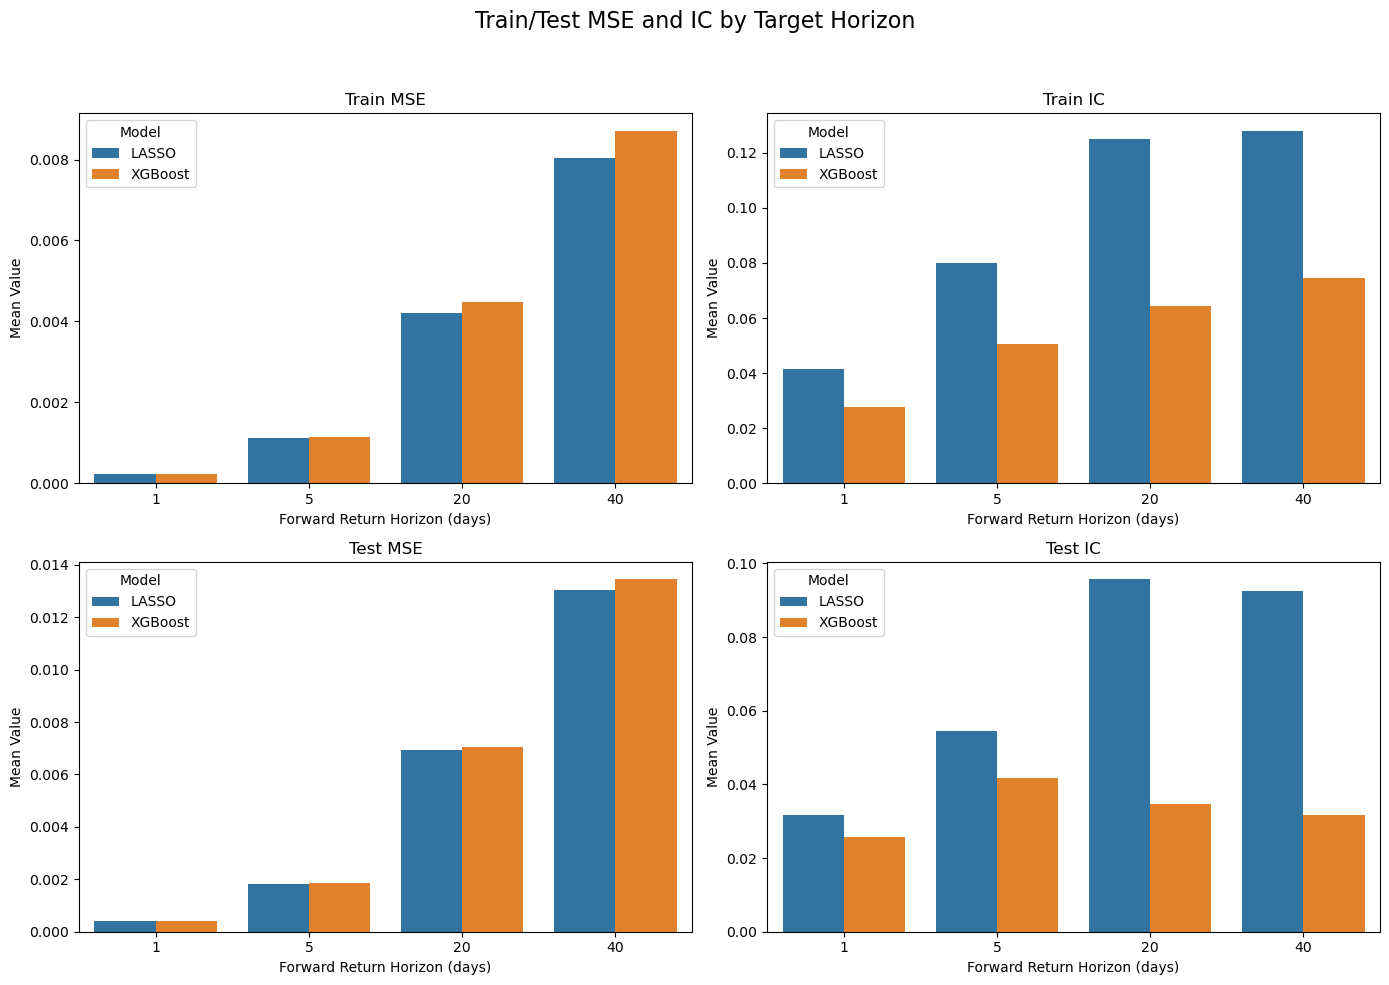

In [10]:
# Step 1: Load results
ml_result = pd.read_csv("model_roll_results.csv")

ml_result['horizon'] = ml_result['target'].str.extract(r'(\d+)').astype(int)

# Step 2: Aggregate metrics
# Compute average MSE and IC over all years, grouped by model and horizon
agg_df = ml_result.groupby(['model', 'horizon']).agg({
    'cv_mse': 'mean',
    'cv_ic': 'mean',
    'test_mse': 'mean',
    'test_ic': 'mean'
}).reset_index()

# Step 3: Reshape for plotting
# Convert to long format for Seaborn compatibility
df_long = agg_df.melt(
    id_vars=['model', 'horizon'], 
    value_vars=['cv_mse', 'cv_ic', 'test_mse', 'test_ic'],
    var_name='metric', value_name='value'
)

# Step 4: Plot grouped bar charts
# Define readable plot titles for each metric
metric_titles = {
    'cv_mse': 'Train MSE',
    'cv_ic': 'Train IC',
    'test_mse': 'Test MSE',
    'test_ic': 'Test IC'
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Train/Test MSE and IC by Target Horizon", fontsize=16)

# Loop through each metric and plot
for ax, metric in zip(axes.flat, metric_titles.keys()):
    subset = df_long[df_long['metric'] == metric]
    sns.barplot(data=subset, x='horizon', y='value', hue='model', ax=ax)
    ax.set_title(metric_titles[metric])
    ax.set_xlabel("Forward Return Horizon (days)")
    ax.set_ylabel("Mean Value")
    ax.legend(title='Model')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [11]:
df.head()

,date,ticker,fwd_return_1d,fwd_return_5d,fwd_return_20d,fwd_return_40d,daily_rf_return,vrp_std_250,PE_RATIO_signal_60,PX_TO_BOOK_RATIO_signal_60,...,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10
0,2012-01-03,ACN,-0.000378,-0.006044,0.103301,0.127093,2.023810e-07,-0.256872,0.833333,0.766667,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2012-01-04,ACN,-0.019082,0.013979,0.091433,0.125999,4.047619e-07,-0.284793,0.866667,0.800000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2012-01-05,ACN,-0.001734,0.038904,0.123066,0.172557,4.047619e-07,-0.251431,1.000000,1.000000,...,2.909493,2.326281,-2.029736,-3.413825,-3.978282,6.391789,-0.606362,0.737494,-4.288784,0.978919
3,2012-01-06,ACN,-0.001737,0.027396,0.112479,0.147204,2.023810e-07,-0.314582,1.000000,1.000000,...,-1.945159,-1.848580,-8.092597,-1.757033,5.969116,3.186429,-4.933686,3.633891,-2.517397,-2.546766
4,2012-01-09,ACN,0.017201,0.033822,0.120212,0.152099,2.023810e-07,-0.244131,1.000000,1.000000,...,-4.696823,-2.063582,-8.359034,-1.251525,7.156292,3.032311,-0.968353,5.361225,0.614748,-2.746181


In [12]:
# Columns to drop
cols_to_drop = ['fwd_return_1d', 'fwd_return_5d', 'fwd_return_20d', 'daily_rf_return']

# Drop
df.drop(columns=cols_to_drop, inplace=True)

In [13]:
print(df.columns.tolist())

['date', 'ticker', 'fwd_return_40d', 'vrp_std_250', 'PE_RATIO_signal_60', 'PX_TO_BOOK_RATIO_signal_60', 'PX_TO_SALES_RATIO_signal_60', 'PX_LAST_EWMA_signal_span60', 'crossover_signal', 'classic_breakout_60_20', 'cont_breakout_mu60_lam5_d0.9', 'RSI_signal_60', 'momentum_60d', 'momentum_20d', 'momentum_200d', 'momentum_220d', 'momentum_80d', 'macd_signal_15_60', 'pca_1', 'pca_2', 'pca_3', 'pca_4', 'pca_5', 'pca_6', 'pca_7', 'pca_8', 'pca_9', 'pca_10']


## 5. LASSO Rolling Training and Hyperparameter Tuning

---

### Objective

Use LASSO regression to predict 40-day forward returns. The model is trained in a rolling way and tuned using cross-validation.

---

### Key Points

- **Model**: LASSO (linear regression with L1 penalty), helps pick important features  
- **Target**: `fwd_return_40d`  
- **Features**: All numeric columns, except date, ticker, and target

---

### Cross-Validation and Grid Search

- Expanding-window cross-validation is used  
- For each test year:
  - Train on the last 5 years  
  - Validate on several 6-month chunks before the test year  
- A grid of 50 `alpha` values is tested, ranging from $10^{-8}$ to $10^{-2}$  
- The best `alpha` is picked using validation MSE

---

### Rolling Training and Prediction

- After choosing the best `alpha`, train the model again using all training data  
- Predict returns for the next year (test period)  
- Evaluate using:
  - **MSE**: average squared error between predictions and actual values  
  - **IC**: Spearman correlation between predicted and actual ranks


In [14]:
# Step 1: Date Parsing
df['date'] = pd.to_datetime(df['date'])

# Step 2: Feature Setup
forward_targets = ['fwd_return_40d']
exclude_cols = ['date', 'ticker'] + forward_targets
feature_cols = [c for c in df.columns if c not in exclude_cols]

# Step 3: Param Grid Search
def param_grid_dicts(grid):
    keys = list(grid.keys())
    for values in product(*[grid[k] for k in keys]):
        yield dict(zip(keys, values))

# Step 4: Evaluate on Folds
def evaluate_on_folds(df, folds, features, target, params):
    mse_list, ic_list = [], []

    for fold in folds:
        train_mask = (df['date'] >= fold['train_start']) & (df['date'] <= fold['train_end'])
        val_mask = (df['date'] >= fold['val_start']) & (df['date'] <= fold['val_end'])

        X_train = df.loc[train_mask, features].fillna(0.0).values
        y_train = df.loc[train_mask, target].values
        X_val = df.loc[val_mask, features].fillna(0.0).values
        y_val = df.loc[val_mask, target].values

        model = Lasso(**params, random_state=42, max_iter=10000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        mse_list.append(mean_squared_error(y_val, y_pred))
        ic_list.append(spearmanr(y_val, y_pred).correlation)

    return float(np.mean(mse_list)), float(np.mean(ic_list))

# Step 5: Expanding CV Splits
def create_expanding_cv_splits(df, test_years, train_years=5, min_cv_folds=5):
    splits = []
    for test_year in test_years:
        test_start = pd.Timestamp(f"{test_year}-01-01")
        test_end = pd.Timestamp(f"{test_year}-12-31")
        train_start = test_start - pd.DateOffset(years=train_years)
        train_end = test_start - pd.Timedelta(days=1)

        val_start = train_start + pd.DateOffset(years=2, months=6)
        val_folds = []

        while True:
            val_end = (val_start + pd.DateOffset(months=6)) - pd.DateOffset(months=1)
            val_end = pd.Timestamp(val_end.year, val_end.month, 1) + pd.offsets.MonthEnd(0)
            if val_end > train_end:
                break
            train_fold_end = val_start - pd.Timedelta(days=1)
            val_folds.append({
                'train_start': train_start, 'train_end': train_fold_end,
                'val_start': val_start, 'val_end': val_end
            })
            val_start += pd.DateOffset(months=6)

        if len(val_folds) >= min_cv_folds:
            splits.append({
                'test_year': test_year,
                'train_period': (train_start, train_end),
                'test_period': (test_start, test_end),
                'cv_folds': val_folds
            })
    return splits

# Step 6: Rolling LASSO Training
def run_roll_training_lasso_only(df, test_years):
    results = []

    lasso_grid = {'alpha': np.logspace(-8, -2, 50)}
    splits = create_expanding_cv_splits(df, test_years=test_years)

    for split in tqdm(splits, desc="Rolling Test Years"):
        test_year = split['test_year']
        train_start, train_end = split['train_period']
        test_start, test_end = split['test_period']
        folds = split['cv_folds']

        full_train_df = df[(df['date'] >= train_start) & (df['date'] <= train_end)]
        test_df = df[(df['date'] >= test_start) & (df['date'] <= test_end)]

        target = 'fwd_return_40d'
        best_mse, best_ic, best_params = np.inf, -np.inf, None

        for p in tqdm(list(param_grid_dicts(lasso_grid)), desc=f"[{test_year}] LASSO Grid", leave=False):
            cv_mse, cv_ic = evaluate_on_folds(df, folds, feature_cols, target, p)
            if (cv_mse < best_mse) or (np.isclose(cv_mse, best_mse) and cv_ic > best_ic):
                best_mse, best_ic, best_params = cv_mse, cv_ic, p.copy()

        lasso_model = Lasso(**best_params, random_state=42, max_iter=1000000)
        lasso_model.fit(full_train_df[feature_cols].fillna(0.0), full_train_df[target])
        y_pred = lasso_model.predict(test_df[feature_cols].fillna(0.0))

        results.append({
            'test_year': test_year,
            'target': target,
            'model': 'LASSO',
            'cv_mse': best_mse,
            'cv_ic': best_ic,
            'test_mse': mean_squared_error(test_df[target], y_pred),
            'test_ic': spearmanr(test_df[target], y_pred).correlation,
            'best_params': best_params
        })

    return pd.DataFrame(results)

In [15]:
test_years = [2017, 2018, 2019, 2020]
results_lasso_df = run_roll_training_lasso_only(df, test_years=test_years)
results_lasso_df.to_csv("lasso_results.csv", index=False)

Rolling Test Years: 100%|█████████████████████████| 4/4 [01:59<00:00, 30.00s/it]


## 6. LASSO Rolling Training and Feature Importance Analysis

---

### Model Training

LASSO is retrained each year using the best `alpha` found in cross-validation.  

- A 5-year rolling training window is used for each year  
- The model makes predictions on both training and test sets  
- Coefficients from each model are saved to track feature weights over time

---

### Prediction Integration

Model predictions (`lasso_pred`) are added back into the full dataset.  
Each row is labeled with its test year and whether it's from the training or test set.

---

### Feature Importance Metrics

The following statistics are calculated using yearly LASSO coefficients:

- `mean_coef`: average signed coefficient across years  
- `mean_abs_coef`: average absolute value, used to rank importance  
- `std_coef`: how much the coefficient changes over years  
- `nonzero_pct`: percentage of years where the feature's coefficient is not zero  

The 20 features with the highest `mean_abs_coef` are chosen for further review.

---

### Visualization

Two visual tools are used to explain feature behavior:

- **Bar Chart**: Shows `mean_abs_coef` for the top 20 features, giving a sense of their overall strength  
- **Heatmap**: Displays how each feature’s coefficient changes year by year

---

### Feature Importance Analysis from LASSO Coefficients

---

#### Bar Chart: Mean Absolute Coefficients

The first plot ranks the top 20 features by their mean absolute LASSO coefficients across test years:

- `PE_RATIO_signal_60` and `momentum_200d` have the highest values, indicating strong and stable predictive power.  
- `vrp_std_250` (volatility signal) and `PX_TO_BOOK_RATIO_signal_60` (valuation) also contribute meaningfully.  
- Several PCA-based text features appear in the top ranks, showing that FinBERT-derived embeddings having useful information.  
- Breakout and MACD trend signals are also included, showing that basic price signals are useful.

---

#### Heatmap: Coefficient Stability Over Time

The second plot shows year-by-year LASSO coefficients for the top 20 features:

- `PE_RATIO_signal_60` and `momentum_200d` stay consistently positive across all years.  
- Other features such as `vrp_std_250` and `PX_TO_BOOK_RATIO_signal_60` show some variation but remain relevant.  
- Lower-ranked features like PCA components, `RSI_signal_60`, and `momentum_60d` show weaker and less stable coefficients.  
- Some coefficients are zero in certain years due to LASSO’s sparsity constraint, reflecting its built-in feature selection.

---

100%|█████████████████████████████████████████████| 4/4 [00:00<00:00, 15.23it/s]


                              mean_coef  mean_abs_coef  std_coef  nonzero_pct
PE_RATIO_signal_60             0.005624       0.005624  0.006508         0.50
momentum_200d                  0.004485       0.004485  0.005226         0.50
vrp_std_250                    0.002681       0.002681  0.004650         0.50
PX_TO_BOOK_RATIO_signal_60     0.001452       0.001452  0.002005         0.50
pca_8                          0.001073       0.001073  0.001270         0.50
cont_breakout_mu60_lam5_d0.9   0.000814       0.000814  0.000901         0.75
classic_breakout_60_20         0.000745       0.000745  0.001490         0.25
momentum_220d                  0.000387       0.000387  0.000774         0.25
pca_10                        -0.000319       0.000319  0.000419         0.50
pca_4                         -0.000255       0.000255  0.000301         0.50
pca_6                          0.000160       0.000160  0.000250         0.50
pca_1                          0.000093       0.000093  0.000128

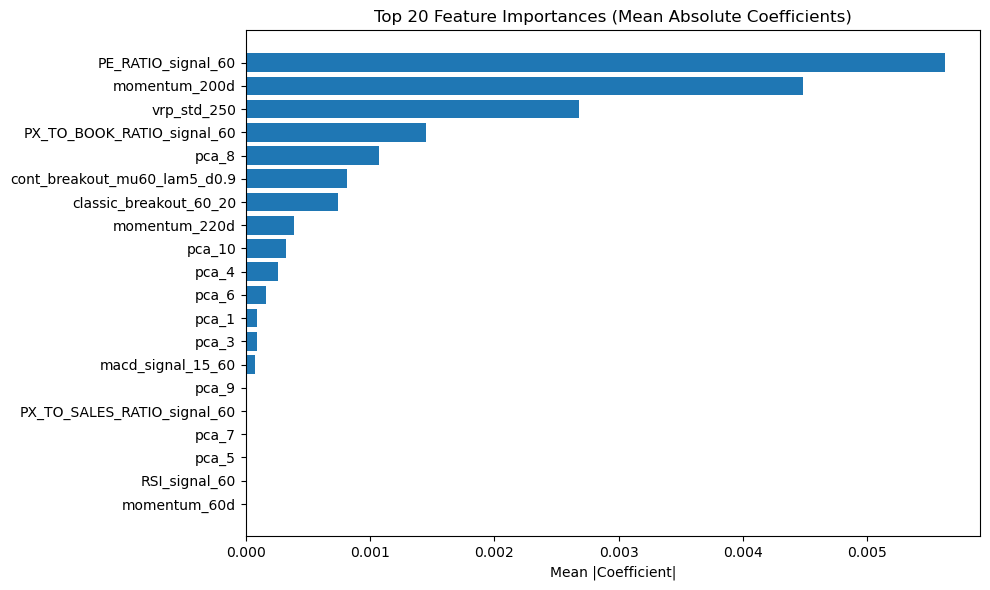

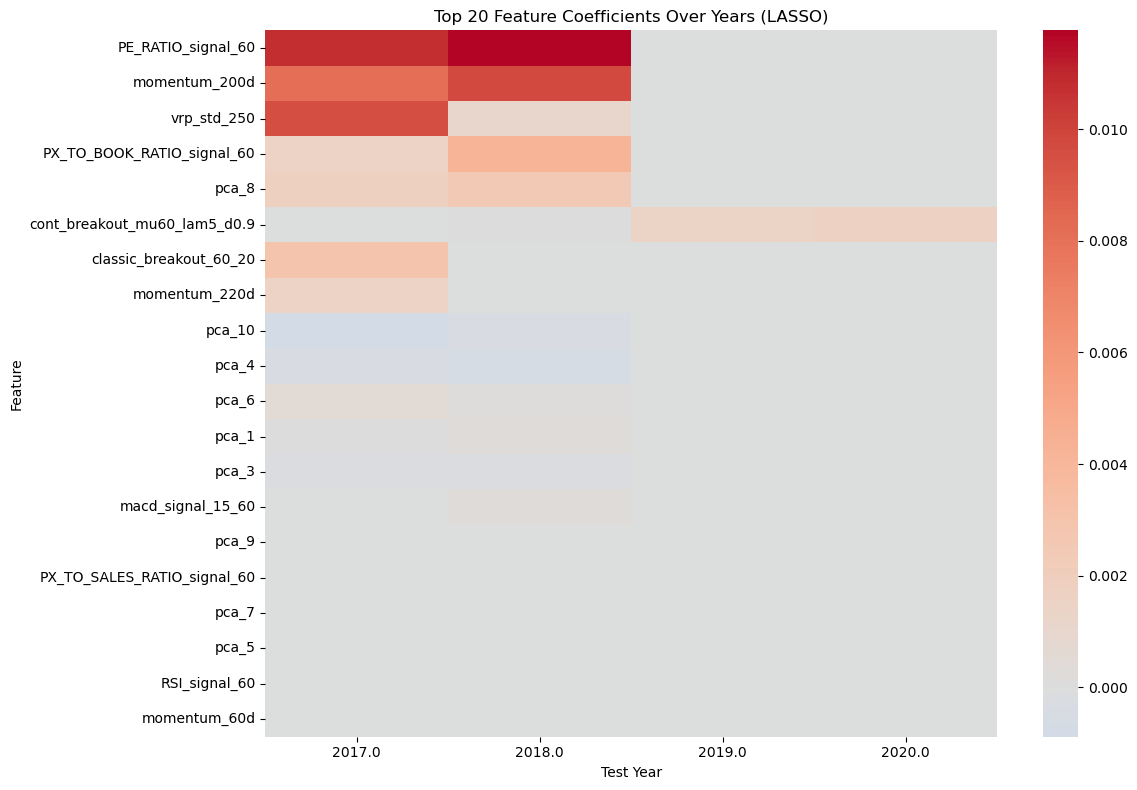

In [16]:
# Step 1: Load LASSO optimal parameters
lasso_result_df = pd.read_csv("lasso_results.csv")
lasso_result_df = lasso_result_df[lasso_result_df['target'] == 'fwd_return_40d']

# Step 2: Define target and feature columns
target_col = 'fwd_return_40d'
exclude_cols = ['date', 'ticker', target_col, 'lasso_pred', 'test_year', 'dataset']
feature_cols = [c for c in df.columns if c not in exclude_cols and df[c].dtype in [np.float64, np.float32, np.int64]]

# Step 3: Rolling training and prediction
results = []
coef_list = []

for _, row in tqdm(lasso_result_df.iterrows(), total=len(lasso_result_df)):
    year = int(row['test_year'])
    alpha = float(eval(row['best_params'])['alpha'])

    train_start = pd.Timestamp(f"{year - 5}-01-01")
    train_end   = pd.Timestamp(f"{year - 1}-12-31")
    test_start  = pd.Timestamp(f"{year}-01-01")
    test_end    = pd.Timestamp(f"{year}-12-31")

    train_df = df[(df['date'] >= train_start) & (df['date'] <= train_end)].copy()
    test_df  = df[(df['date'] >= test_start) & (df['date'] <= test_end)].copy()

    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    model.fit(train_df[feature_cols].fillna(0.0), train_df[target_col])

    coef_series = pd.Series(model.coef_, index=feature_cols)
    coef_series['year'] = year
    coef_series['alpha'] = alpha
    coef_list.append(coef_series)

    train_df['lasso_pred'] = model.predict(train_df[feature_cols].fillna(0.0))
    train_df['test_year'] = year
    train_df['dataset'] = 'train'

    test_df['lasso_pred'] = model.predict(test_df[feature_cols].fillna(0.0))
    test_df['test_year'] = year
    test_df['dataset'] = 'test'

    results.append(train_df[['date', 'ticker', 'lasso_pred', 'test_year', 'dataset']])
    results.append(test_df[['date', 'ticker', 'lasso_pred', 'test_year', 'dataset']])

# Step 4: Merge predictions back to original df
pred_df = pd.concat(results).reset_index(drop=True)
df = df.merge(pred_df, on=['date', 'ticker'], how='left')

# Step 5: Feature importance analysis
coef_df = pd.DataFrame(coef_list)
feature_cols_only = [col for col in coef_df.columns if col not in ['year', 'alpha']]

coef_summary = pd.DataFrame({
    'mean_coef': coef_df[feature_cols_only].mean(),
    'mean_abs_coef': coef_df[feature_cols_only].abs().mean(),
    'std_coef': coef_df[feature_cols_only].std(),
    'nonzero_pct': (coef_df[feature_cols_only] != 0).sum() / len(coef_df)
}).sort_values(by='mean_abs_coef', ascending=False)

top_n = 20
top_features = coef_summary.head(top_n)
print(top_features)

# Step 6: Bar chart of mean absolute coefficients
plt.figure(figsize=(10, 6))
plt.barh(top_features.index[::-1], top_features['mean_abs_coef'][::-1])
plt.title(f"Top {top_n} Feature Importances (Mean Absolute Coefficients)")
plt.xlabel("Mean |Coefficient|")
plt.tight_layout()
plt.show()

# Step 7: Heatmap of coefficients over years
plt.figure(figsize=(12, 8))
sns.heatmap(
    coef_df.set_index('year')[top_features.index].T,
    center=0, cmap='coolwarm', annot=False
)
plt.title(f"Top {top_n} Feature Coefficients Over Years (LASSO)")
plt.xlabel("Test Year")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 7. LASSO Daily Directional Accuracy Analysis

---

#### Purpose

Evaluate how well the LASSO model predicts the **direction** (sign) of forward 40-day returns, separately on training and test sets.

---

#### Method

1. **Direction Match Definition**  
   A prediction is counted as correct if it has the **same sign** as the actual return:
   - Positive if both prediction and return are > 0  
   - Negative if both are < 0  

2. **Daily Aggregation**  
   For each date, compute the proportion of stocks where the predicted and actual signs match. This yields a **daily match ratio** between 0 and 1.

3. **Visualization**  
   Plot the time series of daily directional accuracy. A horizontal line at 0.5 is added as a benchmark, representing **random guessing**.

---

## **Chart Analysis**

---

#### Test Set Performance

- Accuracy stays above the 50% baseline for most days between 2017 and 2020.
- Several windows reach **60%–80%** accuracy, showing the model captures return direction well in those periods.
- Occasional drops below 50% may be due to market changes or noise.

---

#### Train Set Performance

- From 2011 to 2019, directional accuracy is often **above 70%**, with some peaks near **90%**.
- The model learns strong directional signals, though performance still varies across time.

---

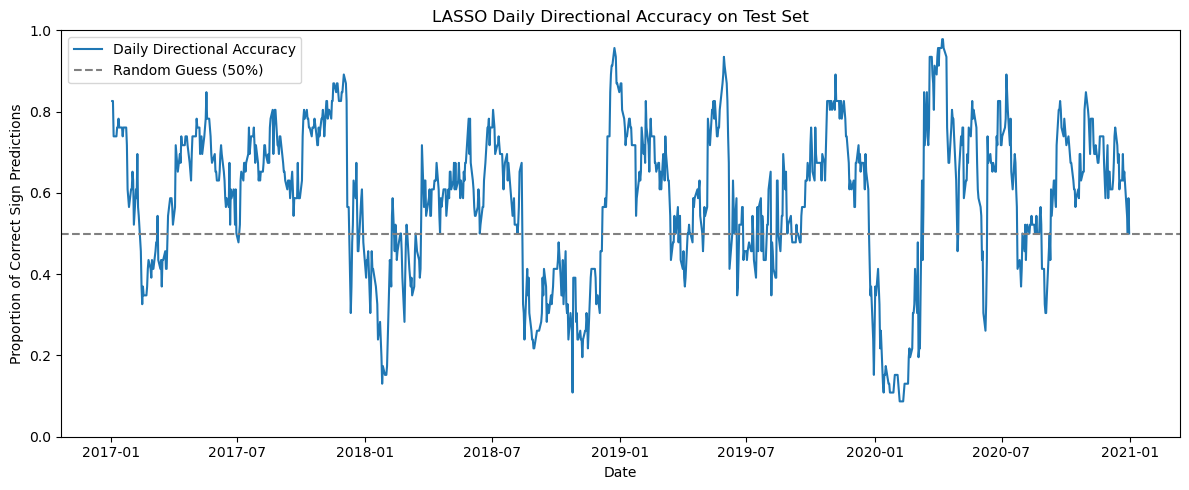

In [17]:
# Step 1: Filter Test Set
test_df = df[df['dataset'] == 'test'].copy()

# Step 2: Define Direction Match
# Whether prediction and actual return have same sign
test_df['direction_match'] = np.sign(test_df['lasso_pred']) == np.sign(test_df['fwd_return_40d'])

# Step 3: Compute Daily Match Ratio
# Group by date and compute daily directional accuracy
daily_match = (
    test_df.groupby('date')['direction_match']
    .mean()
    .reset_index()
    .rename(columns={'direction_match': 'daily_match_ratio'})
)

# Step 4: Visualization
plt.figure(figsize=(12, 5))
plt.plot(daily_match['date'], daily_match['daily_match_ratio'], label='Daily Directional Accuracy')
plt.axhline(0.5, color='gray', linestyle='--', label='Random Guess (50%)')
plt.title('LASSO Daily Directional Accuracy on Test Set')
plt.ylabel('Proportion of Correct Sign Predictions')
plt.xlabel('Date')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

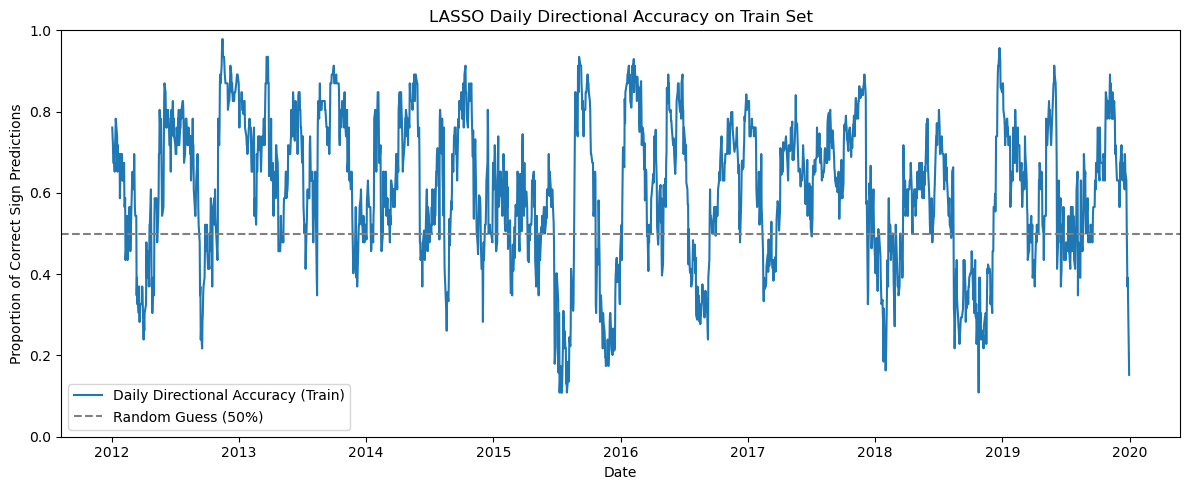

In [18]:
# Step 1: Filter Train Set
train_df = df[df['dataset'] == 'train'].copy()

# Step 2: Define Direction Match
# Whether prediction and actual return have same sign
train_df['direction_match'] = np.sign(train_df['lasso_pred']) == np.sign(train_df['fwd_return_40d'])

# Step 3: Compute Daily Match Ratio
# Group by date and compute daily directional accuracy
daily_match = (
    train_df.groupby('date')['direction_match']
    .mean()
    .reset_index()
    .rename(columns={'direction_match': 'daily_match_ratio'})
)

# Step 4: Visualization
plt.figure(figsize=(12, 5))
plt.plot(daily_match['date'], daily_match['daily_match_ratio'], label='Daily Directional Accuracy (Train)')
plt.axhline(0.5, color='gray', linestyle='--', label='Random Guess (50%)')
plt.title('LASSO Daily Directional Accuracy on Train Set')
plt.ylabel('Proportion of Correct Sign Predictions')
plt.xlabel('Date')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
df.head()
df.to_csv("df_with_lasso_predict.csv", index=False)

## 8. Grid Search for Long-Short Strategy Configuration

---

### Train Set Selection

To avoid overfitting, strategy parameters are tuned using only 2017 data. Earlier training years (2012–2016) are excluded from this process to prevent using future information. This makes 2017 a clean and unbiased year for testing different strategy settings before applying them to the actual test period (2018–2020).

---

### Parameter Grid

The grid includes the following:

| Parameter          | Meaning                                | Range   |
|--------------------|----------------------------------------|---------|
| `top_long`         | Number of long positions per rebalance | 1 to 5  |
| `top_short`        | Number of short positions per rebalance| 1 to 5  |
| `rebalance_period` | Days between each rebalance            | 35 to 40 |

Each combination is tested based on 2017 performance only.

---

### Backtest Procedure

- - Overlapping execution dates are selected within 2017.  
- On each selected date:
  - Top N stocks with the highest `lasso_pred` values are chosen as long positions.
  - Bottom M stocks with the lowest `lasso_pred` values are chosen as short positions.
  - The realized return is computed using the forward 40-day return window, which overlaps across days.
- On each rebalance day:
  - Take top N stocks with the highest `lasso_pred` values for long positions.
  - Take bottom M stocks with the lowest `lasso_pred` values for short positions.
  - Compute the average 40-day forward return for both groups.
- The net return is:

  $$
  r_{\text{net}} = r_{\text{long}} - r_{\text{short}}
  $$

---

### Evaluation Metrics

Two metrics are used to compare configurations:

- **Sharpe Ratio**:

  $$
  \text{Sharpe} = \frac{\text{mean}(r)}{\text{std}(r)}
  $$

- **Maximum Drawdown (MDD)**:

  $$
  \text{MDD} = \max_t \left(1 - \frac{R_t}{\max_{s \leq t} R_s} \right)
  $$

  where $R_t$ is the cumulative return on day $t$.

---

### Selection Rule

The configuration with the **smallest maximum drawdown** is chosen. 

---


Best max drawdown config:
top_long             3.000000
top_short            2.000000
rebalance_period    37.000000
sharpe               1.400662
max_drawdown        -0.013604
Name: 68, dtype: float64


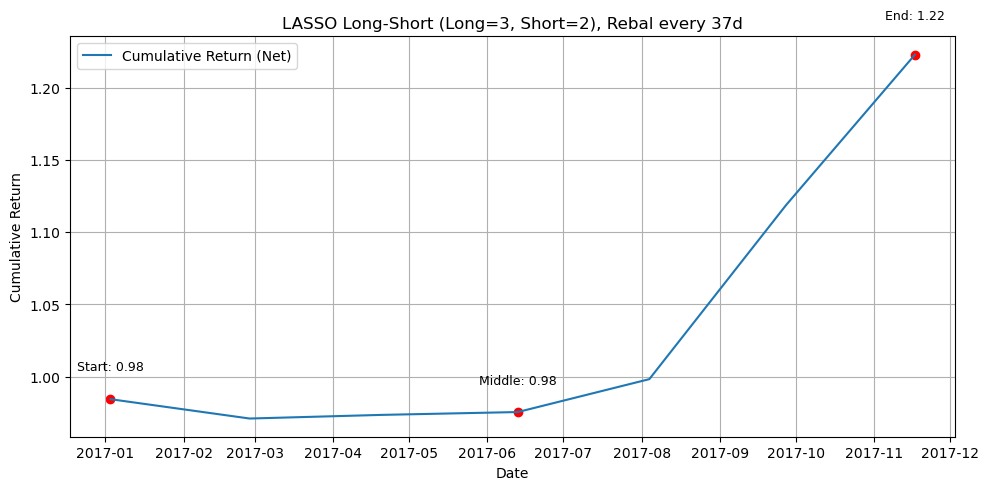

In [20]:
# Backtest function
def backtest_long_short(df, top_long, top_short, rebalance_period):
    df = df[(df['date'] >= pd.Timestamp("2017-01-01")) & (df['date'] <= pd.Timestamp("2017-12-31"))].copy()
    all_dates = df['date'].drop_duplicates().sort_values().reset_index(drop=True)
    rebal_dates = all_dates[::rebalance_period]

    portfolio_returns = []

    for reb_date in rebal_dates:
        group = df[df['date'] == reb_date]

        # Long positions
        long_candidates = group[group['lasso_pred'] > 0]
        long_group = long_candidates.nlargest(min(top_long, len(long_candidates)), 'lasso_pred')
        long_return = long_group['fwd_return_40d'].mean() if not long_group.empty else 0.0

        # Short positions
        short_candidates = group[group['lasso_pred'] < 0]
        short_group = short_candidates.nsmallest(min(top_short, len(short_candidates)), 'lasso_pred')
        short_return = short_group['fwd_return_40d'].mean() if not short_group.empty else 0.0

        net_return = long_return - short_return

        portfolio_returns.append({
            'date': reb_date,
            'long_return': long_return,
            'short_return': short_return,
            'net_return': net_return
        })

    return pd.DataFrame(portfolio_returns)


# Performance evaluation
def evaluate_performance(returns_df, rebalance_period):
    ret = returns_df['net_return']
    if ret.std(ddof=1) == 0:
        sharpe = 0.0
    else:
        sharpe = ret.mean() / ret.std(ddof=1) * np.sqrt(252 / 40)

    cum_ret = (1 + ret).cumprod()
    peak = cum_ret.cummax()
    drawdown = (cum_ret - peak) / peak
    max_dd = drawdown.min()
    return sharpe, max_dd


# Grid search
results = []

for top_long in range(1, 6):
    for top_short in range(1, 6):
        for rebalance_period in range(35, 41):
            perf_df = backtest_long_short(df, top_long, top_short, rebalance_period)
            sharpe, max_dd = evaluate_performance(perf_df, rebalance_period)
            results.append({
                'top_long': top_long,
                'top_short': top_short,
                'rebalance_period': rebalance_period,
                'sharpe': sharpe,
                'max_drawdown': max_dd
            })

result_df = pd.DataFrame(results)

# Select best
best_row = result_df.sort_values(by='max_drawdown', ascending=False).iloc[0]
print("Best max drawdown config:")
print(best_row)

# Final backtest using best configuration
final_df = backtest_long_short(
    df,
    top_long=int(best_row['top_long']),
    top_short=int(best_row['top_short']),
    rebalance_period=int(best_row['rebalance_period'])
)

final_df = final_df.sort_values('date').copy()
final_df[['long_return', 'short_return', 'net_return']] = final_df[[
    'long_return', 'short_return', 'net_return']].fillna(0.0)
final_df['cum_return'] = (1 + final_df['net_return']).cumprod()

# Plot cumulative return
plt.figure(figsize=(10, 5))
plt.plot(final_df['date'], final_df['cum_return'], label='Cumulative Return (Net)')

# Highlight Start / Middle / End
for idx, label in zip([0, len(final_df) // 2, -1], ['Start', 'Middle', 'End']):
    date = final_df['date'].iloc[idx]
    val = final_df['cum_return'].iloc[idx]
    plt.scatter(date, val, color='red')
    plt.text(date, val * 1.02, f'{label}: {val:.2f}', ha='center', fontsize=9)

plt.title(f"LASSO Long-Short (Long={int(best_row['top_long'])}, Short={int(best_row['top_short'])}), Rebal every {int(best_row['rebalance_period'])}d")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [21]:
def backtest_long_short_every_37_days(df, top_long=3, top_short=2):
    """
    Run long-short backtest strictly on 2018-01-01 to 2020-12-31 (true test set),
    ignoring any 'dataset' labels, rebalancing every 37 trading days.
    """
    df = df[
        (df['date'] >= pd.Timestamp("2018-01-01")) &
        (df['date'] <= pd.Timestamp("2020-12-31"))
    ].copy()

    all_dates = df['date'].drop_duplicates().sort_values().reset_index(drop=True)
    rebal_dates = all_dates[::37]

    portfolio_returns = []

    for reb_date in rebal_dates:
        group = df[df['date'] == reb_date]

        long_candidates = group[group['lasso_pred'] > 0]
        long_group = long_candidates.nlargest(min(top_long, len(long_candidates)), 'lasso_pred')
        long_return = long_group['fwd_return_40d'].mean() if not long_group.empty else 0.0

        short_candidates = group[group['lasso_pred'] < 0]
        short_group = short_candidates.nsmallest(min(top_short, len(short_candidates)), 'lasso_pred')
        short_return = short_group['fwd_return_40d'].mean() if not short_group.empty else 0.0

        net_return = long_return - short_return

        portfolio_returns.append({
            'date': reb_date,
            'long_return': long_return,
            'short_return': short_return,
            'net_return': net_return
        })

    return pd.DataFrame(portfolio_returns)

## 9. Test Set Performance: Long-Short Strategy 

The long-short strategy was tested on the 2018–2020 out-of-sample period using the configuration selected from 2017: long 3 stocks, short 2 stocks, with trades placed every 37 trading days.

The final cumulative return was **1.88**, but the risk-adjusted results were poor. The **Sharpe Ratio** was **0.2962**, and the **maximum drawdown** was **32.99%**.

The low Sharpe Ratio shows that the returns were unstable, while the large drawdown reflects periods of large losses. The biggest drop occurred in early 2020, when the COVID-19 crisis caused global market stress. During that time, the model's signal failed to hold up, likely due to sudden changes in market behavior.


Sharpe Ratio:     0.7435
Max Drawdown:     -0.3299
Final Cumulative Return: 1.88


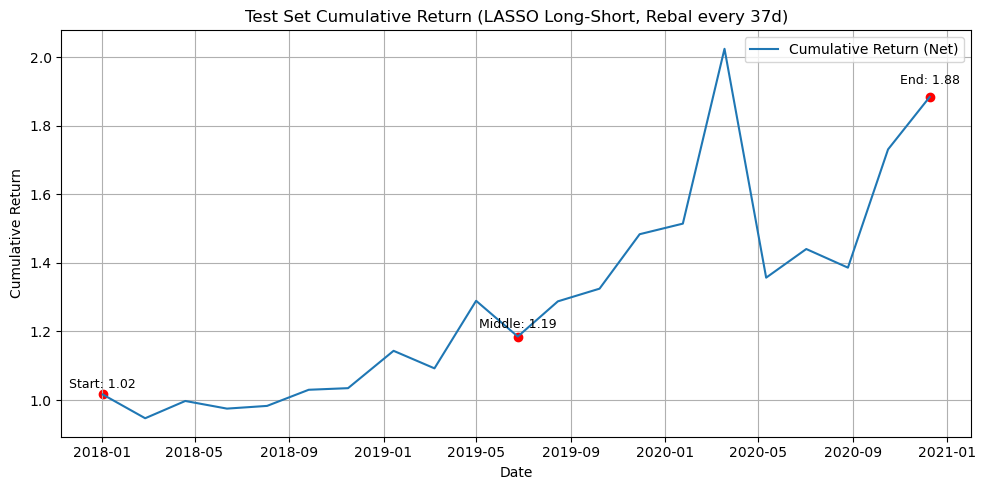

In [22]:
# Step 1: Run backtest on clean test set

# Run backtest using the best configuration
test_df = df[(df['date'] >= pd.Timestamp("2018-01-01")) &
             (df['date'] <= pd.Timestamp("2020-12-31"))].copy()

test_perf_df = backtest_long_short_every_37_days(test_df, top_long=3, top_short=2)

# Sort by date to ensure correct chronological order
test_perf_df = test_perf_df.sort_values('date').copy()

test_perf_df[['long_return', 'short_return', 'net_return']] = test_perf_df[[
    'long_return', 'short_return', 'net_return']].fillna(0.0)

# Compute cumulative return from net returns
test_perf_df['cum_return'] = (1 + test_perf_df['net_return']).cumprod()

# Step 2: Evaluate performance

# Calculate Sharpe ratio, max drawdown, and final cumulative return
sharpe, max_dd = evaluate_performance(test_perf_df, rebalance_period=37)
final_cumret = test_perf_df['cum_return'].iloc[-1]

# Print performance metrics
print(f"Sharpe Ratio:     {sharpe:.4f}")
print(f"Max Drawdown:     {max_dd:.4f}")
print(f"Final Cumulative Return: {final_cumret:.2f}")

# Step 3: Plot cumulative return

plt.figure(figsize=(10, 5))

# Plot cumulative performance
plt.plot(test_perf_df['date'], test_perf_df['cum_return'], label='Cumulative Return (Net)')

# Highlight Start / Middle / End points
for idx, label in zip([0, len(test_perf_df) // 2, -1], ['Start', 'Middle', 'End']):
    date = test_perf_df['date'].iloc[idx]
    val = test_perf_df['cum_return'].iloc[idx]
    plt.scatter(date, val, color='red')
    plt.text(date, val * 1.02, f'{label}: {val:.2f}', ha='center', fontsize=9)

plt.title("Test Set Cumulative Return (LASSO Long-Short, Rebal every 37d)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
df.head()

,date,ticker,fwd_return_40d,vrp_std_250,PE_RATIO_signal_60,PX_TO_BOOK_RATIO_signal_60,PX_TO_SALES_RATIO_signal_60,PX_LAST_EWMA_signal_span60,crossover_signal,classic_breakout_60_20,...,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,lasso_pred,test_year,dataset
0,2012-01-03,ACN,0.127093,-0.256872,0.833333,0.766667,0.833333,0.048264,0.045307,-0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032049,2017,train
1,2012-01-04,ACN,0.125999,-0.284793,0.866667,0.800000,0.866667,0.047104,0.045618,-0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.032187,2017,train
2,2012-01-05,ACN,0.172557,-0.251431,1.000000,1.000000,1.000000,0.063282,0.051096,1.0,...,-3.413825,-3.978282,6.391789,-0.606362,0.737494,-4.288784,0.978919,0.043044,2017,train
3,2012-01-06,ACN,0.147204,-0.314582,1.000000,1.000000,1.000000,0.062912,0.054778,1.0,...,-1.757033,5.969116,3.186429,-4.933686,3.633891,-2.517397,-2.546766,0.048892,2017,train
4,2012-01-09,ACN,0.152099,-0.244131,1.000000,1.000000,1.000000,0.062555,0.057263,1.0,...,-1.251525,7.156292,3.032311,-0.968353,5.361225,0.614748,-2.746181,0.052092,2017,train


## 10. Meta Model Construction

To address poor performance in 2020, especially during market stress, a meta-model was added to filter the daily long-short signals. This model aims to learn when the main strategy is more likely to produce positive returns.

### Label Construction

A binary label was created for each trading day:

- Pick the top 3 stocks by highest `lasso_pred` as long.
- Pick the bottom 2 stocks by lowest `lasso_pred` as short.
- Compute the average 40-day forward return from these 5 positions.
- If the return is positive, label the day as 1; else, label it as 0.

This label reflects whether the strategy would have worked on that day.

### Feature Set

To improve prediction, the following daily features were included:

- Volatility: VIX, SKEW
- Credit spreads: CDX IG, CDX HY
- Option signals: implied forward volatility, bid-ask spread, put-call ratio
- Market index: S&P 500 level (`PX_LAST`)

### Avoiding Look-Ahead Bias

The label was shifted one day backward to make sure no future data was used when training the model.

### Model: AdaBoost

AdaBoost with decision trees was used. This model is simple but effective in handling noisy data. It can find patterns in when the strategy is likely to work.

For each test year (2018–2020), a 5-fold rolling cross-validation over the past 5 years was used to tune the model. ROC AUC was the main score used to choose the best setup. Final predictions were made out-of-sample for each test year.

In [24]:
def construct_meta_labels_daily(df, top_long=3, top_short=2):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'])

    # Get all unique trading dates
    all_dates = df['date'].drop_duplicates().sort_values().reset_index(drop=True)

    meta_records = []

    for current_date in all_dates:
        group = df[df['date'] == current_date]

        # Long candidates with positive lasso prediction
        long_candidates = group[group['lasso_pred'] > 0]
        long_group = long_candidates.nlargest(min(top_long, len(long_candidates)), 'lasso_pred')

        # Short candidates with negative lasso prediction
        short_candidates = group[group['lasso_pred'] < 0]
        short_group = short_candidates.nsmallest(min(top_short, len(short_candidates)), 'lasso_pred')

        # Combine long and short
        combined = pd.concat([long_group, short_group])
        portfolio_return = combined['fwd_return_40d'].mean() if not combined.empty else 0.0

        label = 1 if portfolio_return > 0 else 0
        meta_records.append({'date': current_date, 'label': label})

    meta_df = pd.DataFrame(meta_records)
    return meta_df
    
meta_df = construct_meta_labels_daily(df)
meta_df.head(10)

,date,label
0,2012-01-03,1
1,2012-01-04,1
2,2012-01-05,1
3,2012-01-06,1
4,2012-01-09,1
5,2012-01-10,1
6,2012-01-11,1
7,2012-01-12,1
8,2012-01-13,0
9,2012-01-17,1


In [25]:
# Step 1: Read merged macro data
macro_df = pd.read_csv("merged_macro_data.csv")
macro_df['date'] = pd.to_datetime(macro_df['date'])

# Step 2: Merge (use meta_df as the primary table)
final_meta_df = meta_df.merge(macro_df, on='date', how='left')

# Step 3: Fill missing values in numeric columns with 0
numeric_cols = final_meta_df.select_dtypes(include='number').columns.difference(['label'])
final_meta_df[numeric_cols] = final_meta_df[numeric_cols].fillna(0)

In [26]:
final_meta_df.head()

,date,label,VIX INDEX,SKEW Index,CDX IG CDSI GEN 5Y Corp,CDX HY CDSI GEN 5Y SPRD Corp,PX_LAST_x,PX_LAST_y,IVOL_IMPLIED_FORWARD,PX_BID,PX_ASK,PUT_CALL_VOLUME_RATIO_CUR_DAY
0,2012-01-03,1,22.97,117.10,118.000,0.0,0.0051,1277.06,1277.60,1275.40,1280.44,1.8775
1,2012-01-04,1,22.22,117.63,118.750,0.0,0.0102,1277.30,1275.85,1275.76,1278.22,1.9947
2,2012-01-05,1,21.48,117.76,120.001,0.0,0.0102,1281.06,1279.60,1279.74,1281.92,1.6922
3,2012-01-06,1,20.63,118.29,120.000,0.0,0.0051,1277.81,1277.75,1276.19,1279.42,1.4481
4,2012-01-09,1,21.07,119.07,119.417,0.0,0.0051,1280.70,1279.80,1279.61,1282.04,1.8928


In [27]:
# Step 1: Shift label back one day to prevent leakage
meta_lag_df = final_meta_df.copy()
meta_lag_df['label'] = meta_lag_df['label'].shift(-1)
meta_lag_df['label'] = meta_lag_df['label'].fillna(0).astype(int)

# Step 2: Define features
exclude_cols = ['date', 'label']
feature_cols = [col for col in meta_lag_df.columns if col not in exclude_cols]

# Step 3: CV fold and test split generator
def create_meta_model_folds(meta_lag_df, test_year):
    test_start = pd.Timestamp(f"{test_year}-01-01")
    test_end   = pd.Timestamp(f"{test_year}-12-31")
    train_start = test_start.replace(year=test_year - 5)
    train_end   = test_start - pd.Timedelta(days=1)

    # Train/Test split
    train_data = meta_lag_df[(meta_lag_df['date'] >= train_start) & (meta_lag_df['date'] <= train_end)].copy()
    test_data  = meta_lag_df[(meta_lag_df['date'] >= test_start) & (meta_lag_df['date'] <= test_end)].copy()

    # Define 5 rolling CV folds (6-month validation windows)
    fold_length = pd.DateOffset(months=6)
    fold_start_dates = [
        pd.Timestamp(f"{test_year - 3}-07-01"),
        pd.Timestamp(f"{test_year - 2}-01-01"),
        pd.Timestamp(f"{test_year - 2}-07-01"),
        pd.Timestamp(f"{test_year - 1}-01-01"),
        pd.Timestamp(f"{test_year - 1}-07-01"),
    ]

    folds = []
    for val_start in fold_start_dates:
        val_end = val_start + fold_length - pd.Timedelta(days=1)
        train_mask = train_data['date'] < val_start
        val_mask   = (train_data['date'] >= val_start) & (train_data['date'] <= val_end)

        folds.append({
            'train_X': train_data.loc[train_mask, feature_cols],
            'train_y': train_data.loc[train_mask, 'label'],
            'val_X':   train_data.loc[val_mask, feature_cols],
            'val_y':   train_data.loc[val_mask, 'label'],
        })

    test_X = test_data[feature_cols]
    test_y = test_data['label']

    return folds, test_X, test_y

In [28]:
meta_folds_dict = {}

for year in range(2018, 2021):
    folds, test_X, test_y = create_meta_model_folds(meta_lag_df, test_year=year)
    meta_folds_dict[year] = {
        'folds': folds,
        'test_X': test_X,
        'test_y': test_y
    }

In [29]:
'''
# Step 1: Define hyperparameter grid
param_grid = {
    'n_estimators': [500, 1000],
    'learning_rate': [0.05, 0.01],
    'estimator__max_depth': [1, 3, 10]
}

# Step 2: Store test predictions
all_test_preds = []

# Step 3: Loop over test years
for year in tqdm(range(2018, 2021), desc="Test Years"):
    folds = meta_folds_dict[year]['folds']
    test_X = meta_folds_dict[year]['test_X']
    test_y = meta_folds_dict[year]['test_y']

    # Step 3: Get actual test dates from meta_lag_df
    test_start = pd.Timestamp(f"{year}-01-01")
    test_end   = pd.Timestamp(f"{year}-12-31")
    test_dates = meta_lag_df[
        (meta_lag_df['date'] >= test_start) & 
        (meta_lag_df['date'] <= test_end)
    ]['date'].reset_index(drop=True)

    # Step 3.1: Cross-validation for all param combinations
    def evaluate_params(params):
        cv_scores = []
        base = DecisionTreeClassifier(max_depth=params['estimator__max_depth'])
        clf = AdaBoostClassifier(
            estimator=base,
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate']
        )

        for fold in folds:
            clf.fit(fold['train_X'], fold['train_y'])
            val_preds = clf.predict_proba(fold['val_X'])[:, 1]
            val_auc = roc_auc_score(fold['val_y'], val_preds)
            cv_scores.append(val_auc)

        return {
            'params': params,
            'mean_cv_auc': sum(cv_scores) / len(cv_scores)
        }

    # Parallel CV with progress bar
    param_list = list(ParameterGrid(param_grid))
    results = list(tqdm(
        Parallel(n_jobs=-1)(delayed(evaluate_params)(p) for p in param_list),
        total=len(param_list),
        desc=f"CV for {year}"
    ))

    best_result = max(results, key=lambda x: x['mean_cv_auc'])
    best_params = best_result['params']

    # Step 3.2: Train final model on full training set
    full_train_X = pd.concat([f['train_X'] for f in folds])
    full_train_y = pd.concat([f['train_y'] for f in folds])

    base = DecisionTreeClassifier(max_depth=best_params['estimator__max_depth'])
    final_model = AdaBoostClassifier(
        estimator=base,
        n_estimators=best_params['n_estimators'],
        learning_rate=best_params['learning_rate']
    )
    final_model.fit(full_train_X, full_train_y)

    # Step 3.3: Predict on test set
    test_preds = final_model.predict_proba(test_X)[:, 1]
    test_result_df = pd.DataFrame({
        'date': test_dates.values,
        'test_year': year,
        'pred_prob': test_preds,
        'true_label': test_y.values
    })

    all_test_preds.append(test_result_df)

# Step 4: Combine test results
final_test_predictions = pd.concat(all_test_preds).reset_index(drop=True)

final_test_predictions.to_csv("common_model_meta_prediction.csv", index=False)
'''

'\n# Step 1: Define hyperparameter grid\nparam_grid = {\n    \'n_estimators\': [500, 1000],\n    \'learning_rate\': [0.05, 0.01],\n    \'estimator__max_depth\': [1, 3, 10]\n}\n\n# Step 2: Store test predictions\nall_test_preds = []\n\n# Step 3: Loop over test years\nfor year in tqdm(range(2018, 2021), desc="Test Years"):\n    folds = meta_folds_dict[year][\'folds\']\n    test_X = meta_folds_dict[year][\'test_X\']\n    test_y = meta_folds_dict[year][\'test_y\']\n\n    # Step 3: Get actual test dates from meta_lag_df\n    test_start = pd.Timestamp(f"{year}-01-01")\n    test_end   = pd.Timestamp(f"{year}-12-31")\n    test_dates = meta_lag_df[\n        (meta_lag_df[\'date\'] >= test_start) & \n        (meta_lag_df[\'date\'] <= test_end)\n    ][\'date\'].reset_index(drop=True)\n\n    # Step 3.1: Cross-validation for all param combinations\n    def evaluate_params(params):\n        cv_scores = []\n        base = DecisionTreeClassifier(max_depth=params[\'estimator__max_depth\'])\n        clf 

## 11. Meta Model Filtering Performance

The plot compares the performance of the raw LASSO long-short strategy and the same strategy filtered by a meta-model. Both strategies rebalance every 37 trading days.

### Description

- **Orange dashed line**: Unfiltered LASSO strategy cumulative return.
- **Blue solid line**: Meta-model filtered strategy cumulative return.
- **Black crosses (`X`)**: Rebalance dates where the meta-model skipped trades due to low predicted success.
- **Red dots**: Mark the start, middle, and end values of the filtered strategy.

### Key Observations

- The meta-model avoids most major loss periods, especially during the 2020 market crash.
- Some profitable trades are also filtered out, showing a balance between caution and missed gains.
- The **Sharpe Ratio** improves from **0.2962** (unfiltered) to **0.6857** (filtered), showing more stable return quality.
- **Maximum drawdown** improves from **-0.3299** to **-0.0447**, showing better downside protection.
- The **final cumulative return** increases slightly from **1.88** to **2.11**, showing improved performance even with fewer trades.

These results show that the meta-model improves risk control and overall stability, helping the strategy adapt to different market environments.

Meta Model Sharpe Ratio:           1.7210
Meta Model Max Drawdown:           -0.0447
Meta Model Final Cumulative Return: 2.11


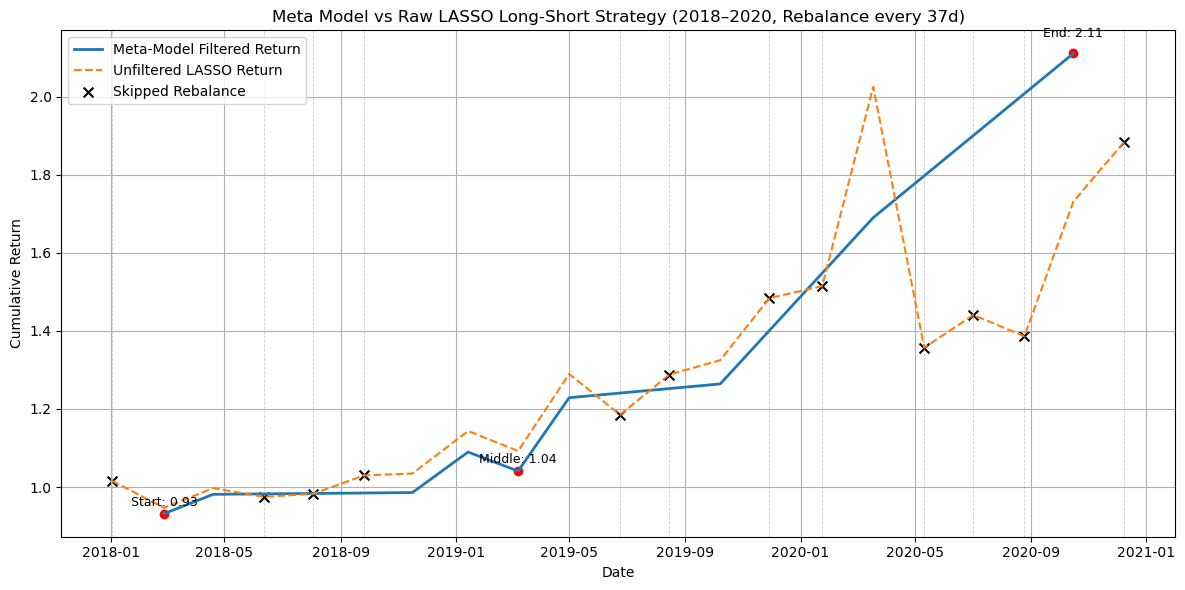

In [30]:
final_test_predictions = pd.read_csv("common_model_meta_prediction.csv")
final_test_predictions['date'] = pd.to_datetime(final_test_predictions['date'])

# Step 1: Identify rebalance days
rebalance_days = df[
    (df['date'] >= pd.Timestamp("2018-01-01")) &
    (df['date'] <= pd.Timestamp("2020-12-31"))
]['date'].drop_duplicates().sort_values().reset_index(drop=True)[::37]

# Step 2: Use meta model to filter rebalance days
meta_threshold = 0.5
active_days = final_test_predictions[
    (final_test_predictions['pred_prob'] > meta_threshold) &
    (final_test_predictions['date'] >= pd.Timestamp("2018-01-01")) &
    (final_test_predictions['date'] <= pd.Timestamp("2020-12-31"))
]['date'].unique()

filtered_rebalance_days = [d for d in rebalance_days if d in active_days]
non_trading_days = [d for d in rebalance_days if d not in active_days]

# Step 3: Backtest for meta-model filtered strategy
meta_bt_results = []

for reb_date in filtered_rebalance_days:
    group = df[df['date'] == reb_date]

    long_candidates = group[group['lasso_pred'] > 0]
    long_group = long_candidates.nlargest(3, 'lasso_pred')

    short_candidates = group[group['lasso_pred'] < 0]
    short_group = short_candidates.nsmallest(2, 'lasso_pred')

    long_return = long_group['fwd_return_40d'].mean() if not long_group.empty else 0.0
    short_return = short_group['fwd_return_40d'].mean() if not short_group.empty else 0.0
    net_return = long_return - short_return

    meta_bt_results.append({
        'date': reb_date,
        'long_return': long_return,
        'short_return': short_return,
        'net_return': net_return
    })

meta_bt_df = pd.DataFrame(meta_bt_results).sort_values('date')
meta_bt_df[['long_return', 'short_return', 'net_return']] = meta_bt_df[[
    'long_return', 'short_return', 'net_return']].fillna(0.0)
meta_bt_df['cum_return'] = (1 + meta_bt_df['net_return']).cumprod()

# Step 4: Evaluate meta-model strategy
sharpe_meta, max_dd_meta = evaluate_performance(meta_bt_df, rebalance_period=37)
final_cumret_meta = meta_bt_df['cum_return'].iloc[-1]

print(f"Meta Model Sharpe Ratio:           {sharpe_meta:.4f}")
print(f"Meta Model Max Drawdown:           {max_dd_meta:.4f}")
print(f"Meta Model Final Cumulative Return: {final_cumret_meta:.2f}")

# Step 5: Backtest using same 2018–2020 window
def backtest_long_short_every_37_days(df, top_long=3, top_short=2):
    df = df[
        (df['date'] >= pd.Timestamp("2018-01-01")) &
        (df['date'] <= pd.Timestamp("2020-12-31"))
    ].copy()

    all_dates = df['date'].drop_duplicates().sort_values().reset_index(drop=True)
    rebal_dates = all_dates[::37]

    portfolio_returns = []

    for reb_date in rebal_dates:
        group = df[df['date'] == reb_date]

        long_candidates = group[group['lasso_pred'] > 0]
        long_group = long_candidates.nlargest(min(top_long, len(long_candidates)), 'lasso_pred')
        long_return = long_group['fwd_return_40d'].mean() if not long_group.empty else 0.0

        short_candidates = group[group['lasso_pred'] < 0]
        short_group = short_candidates.nsmallest(min(top_short, len(short_candidates)), 'lasso_pred')
        short_return = short_group['fwd_return_40d'].mean() if not short_group.empty else 0.0

        net_return = long_return - short_return

        portfolio_returns.append({
            'date': reb_date,
            'long_return': long_return,
            'short_return': short_return,
            'net_return': net_return
        })

    return pd.DataFrame(portfolio_returns)

raw_bt_df = backtest_long_short_every_37_days(df, top_long=3, top_short=2)
raw_bt_df = raw_bt_df.sort_values('date').copy()
raw_bt_df[['long_return', 'short_return', 'net_return']] = raw_bt_df[[
    'long_return', 'short_return', 'net_return'
]].fillna(0.0)
raw_bt_df['cum_return'] = (1 + raw_bt_df['net_return']).cumprod()

# Step 6: Plot cumulative returns
plt.figure(figsize=(12, 6))

plt.plot(meta_bt_df['date'], meta_bt_df['cum_return'], label='Meta-Model Filtered Return', linewidth=2)
plt.plot(raw_bt_df['date'], raw_bt_df['cum_return'], label='Unfiltered LASSO Return', linewidth=1.5, linestyle='--')

for idx, label in zip([0, len(meta_bt_df) // 2, -1], ['Start', 'Middle', 'End']):
    date = meta_bt_df['date'].iloc[idx]
    val = meta_bt_df['cum_return'].iloc[idx]
    plt.scatter(date, val, color='red')
    plt.text(date, val * 1.02, f'{label}: {val:.2f}', ha='center', fontsize=9)

plotted_skipped_label = False
for d in non_trading_days:
    if pd.Timestamp("2018-01-01") <= d <= pd.Timestamp("2020-12-31"):
        plt.axvline(x=d, color='gray', linestyle='--', linewidth=0.6, alpha=0.4)
        y_val = raw_bt_df.loc[raw_bt_df['date'] == d, 'cum_return']
        if not y_val.empty:
            plt.scatter(d, y_val.values[0], marker='x', color='black', s=50,
                        label='Skipped Rebalance' if not plotted_skipped_label else "")
            plotted_skipped_label = True

plt.title("Meta Model vs Raw LASSO Long-Short Strategy (2018–2020, Rebalance every 37d)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## 12. Comparison of Portfolio Weighting Schemes under Meta-Model Strategy

This figure compares the cumulative returns of three portfolio weighting methods applied to meta-model filtered trading signals:

- Equal Weight  
- Volatility Parity  
- Risk Parity  
- Unfiltered LASSO (dashed red line for reference)  

All strategies rebalance every 37 trading days from 2018 to 2020, using the same long-short signals (long 3, short 2) filtered by the meta-model.

### Performance Summary

- Equal Weight  
  - Sharpe Ratio: 0.6857  
  - Max Drawdown: 0.0447  
  - Final Cumulative Return: 2.11  

- Volatility Parity  
  - Sharpe Ratio: 0.6436  
  - Max Drawdown: 0.0457  
  - Final Cumulative Return: 1.91  

- Risk Parity  
  - Sharpe Ratio: 0.4290  
  - Max Drawdown: 0.2207  
  - Final Cumulative Return: 1.79  

### Key Observations

- Equal Weight delivers the best balance between return and risk, achieving the highest final cumulative return and low drawdown.

### Conclusion

Among the three weighting approaches, Equal Weight proves most effective under the meta-model framework. 


| Strategy           | Sharpe Ratio | Max Drawdown | Final Cumulative Return |
|--------------------|--------------|--------------|--------------------------|
| Equal Weight       | 1.721        | 0.0447       | 2.11                     |
| Volatility Parity  | 1.6154       | 0.0457       | 1.91                     |
| Risk Parity        | 1.0768       | 0.2207       | 1.79                     |


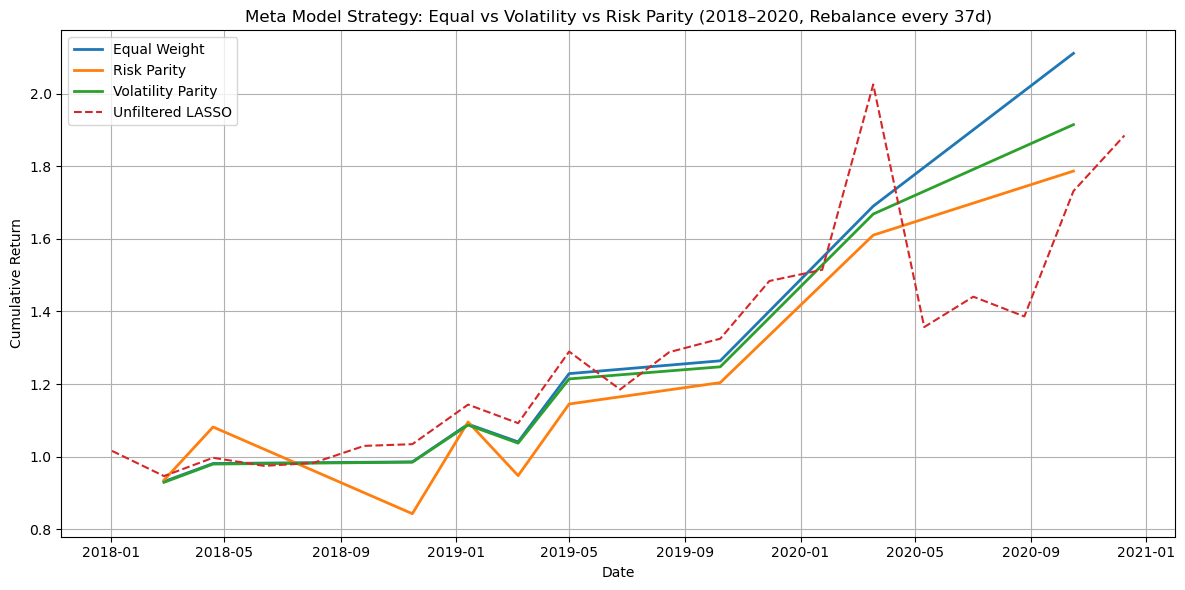

In [31]:
# Load price data
px_df = pd.read_csv("filtered_pxlast_2010_2022.csv")
px_df['date'] = pd.to_datetime(px_df['date'])

# Overlapping setup
rebalance_days = df[
    (df['date'] >= pd.Timestamp("2018-01-01")) &
    (df['date'] <= pd.Timestamp("2020-12-31"))
]['date'].drop_duplicates().sort_values().reset_index(drop=True)[::37]

meta_threshold = 0.5
active_days = final_test_predictions[
    (final_test_predictions['pred_prob'] > meta_threshold) &
    (final_test_predictions['date'] >= pd.Timestamp("2018-01-01")) &
    (final_test_predictions['date'] <= pd.Timestamp("2020-12-31"))
]['date'].unique()

filtered_rebalance_days = [d for d in rebalance_days if d in active_days]
non_trading_days = [d for d in rebalance_days if d not in active_days]

meta_bt_results_eq = []
meta_bt_results_vp = []
meta_bt_results_rp = []

# Main backtest loop
for reb_date in filtered_rebalance_days:
    group = df[df['date'] == reb_date].copy()
    long_group = group[group['lasso_pred'] > 0].nlargest(3, 'lasso_pred')
    short_group = group[group['lasso_pred'] < 0].nsmallest(2, 'lasso_pred')
    all_tickers = list(long_group['ticker']) + list(short_group['ticker'])

    # Equal Weight
    long_eq_ret = long_group['fwd_return_40d'].mean() if not long_group.empty else 0.0
    short_eq_ret = short_group['fwd_return_40d'].mean() if not short_group.empty else 0.0
    net_eq_ret = long_eq_ret - short_eq_ret
    meta_bt_results_eq.append({'date': reb_date, 'net_return': net_eq_ret})

    # Volatility Parity
    def estimate_vol(ticker):
        px = px_df[(px_df['ticker'] == ticker) & (px_df['date'] < reb_date)].sort_values('date').tail(40)
        px_ret = np.log(px['PX_LAST'] / px['PX_LAST'].shift(1)).dropna()
        return px_ret.std() if not px_ret.empty else 1.0

    long_group['vol'] = long_group['ticker'].apply(estimate_vol)
    short_group['vol'] = short_group['ticker'].apply(estimate_vol)
    long_group['weight'] = 1.0 / long_group['vol']
    short_group['weight'] = 1.0 / short_group['vol']
    long_group['weight'] /= long_group['weight'].sum()
    short_group['weight'] /= short_group['weight'].sum()

    long_vp_ret = (long_group['fwd_return_40d'] * long_group['weight']).sum()
    short_vp_ret = (short_group['fwd_return_40d'] * short_group['weight']).sum()
    net_vp_ret = long_vp_ret - short_vp_ret
    meta_bt_results_vp.append({'date': reb_date, 'net_return': net_vp_ret})

    # Risk Parity
    px_slice = px_df[(px_df['ticker'].isin(all_tickers)) & (px_df['date'] <= reb_date)]
    px_pivot = px_slice.pivot(index='date', columns='ticker', values='PX_LAST').sort_index()
    px_window = px_pivot.tail(40)
    ret_mat = np.log(px_window / px_window.shift(1)).dropna()
    cov_matrix = ret_mat.cov()
    inv_vol = 1.0 / np.sqrt(np.diag(cov_matrix))
    inv_vol = pd.Series(inv_vol, index=cov_matrix.columns)
    rp_weights = inv_vol / inv_vol.sum()

    returns = group.set_index('ticker').loc[all_tickers]['fwd_return_40d']
    net_rp_ret = np.dot(rp_weights.loc[returns.index], returns)
    meta_bt_results_rp.append({'date': reb_date, 'net_return': net_rp_ret})

# Cumulative return DataFrames
def build_cum_return_df(bt_result_list, label):
    df_bt = pd.DataFrame(bt_result_list).sort_values('date')
    df_bt['net_return'] = df_bt['net_return'].fillna(0.0)
    df_bt['cum_return'] = (1 + df_bt['net_return']).cumprod()
    df_bt['strategy'] = label
    return df_bt[['date', 'cum_return', 'strategy', 'net_return']]

df_eq = build_cum_return_df(meta_bt_results_eq, 'Equal Weight')
df_vp = build_cum_return_df(meta_bt_results_vp, 'Volatility Parity')
df_rp = build_cum_return_df(meta_bt_results_rp, 'Risk Parity')
plot_df = pd.concat([df_eq, df_vp, df_rp])

# Evaluation metrics
def evaluate(df):
    sharpe = df['net_return'].mean() / df['net_return'].std() * np.sqrt(252 / 40)
    cum = df['cum_return'].iloc[-1]
    hwm = df['cum_return'].cummax()
    dd = 1 - df['cum_return'] / hwm
    mdd = dd.max()
    return sharpe, mdd, cum

metrics = []
for name, df_strategy in zip(['Equal Weight', 'Volatility Parity', 'Risk Parity'], [df_eq, df_vp, df_rp]):
    s, mdd, cumret = evaluate(df_strategy)
    metrics.append({'Strategy': name, 'Sharpe': round(s, 4), 'Max DD': round(mdd, 4), 'Final Return': round(cumret, 2)})

print("\n| Strategy           | Sharpe Ratio | Max Drawdown | Final Cumulative Return |")
print("|--------------------|--------------|--------------|--------------------------|")
for row in metrics:
    print(f"| {row['Strategy']:<18} | {row['Sharpe']:<12} | {row['Max DD']:<12} | {row['Final Return']:<24} |")

# Load and filter raw_bt_df
raw_bt_plot = raw_bt_df[
    (raw_bt_df['date'] >= pd.Timestamp("2018-01-01")) &
    (raw_bt_df['date'] <= pd.Timestamp("2020-12-31"))
].copy()

# Plot
plt.figure(figsize=(12, 6))
for label, group in plot_df.groupby('strategy'):
    plt.plot(group['date'], group['cum_return'], label=label, linewidth=2)

plt.plot(raw_bt_plot['date'], raw_bt_plot['cum_return'], label='Unfiltered LASSO', linestyle='--', linewidth=1.5)

plt.title("Meta Model Strategy: Equal vs Volatility vs Risk Parity (2018–2020, Rebalance every 37d)")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()